In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

import scienceplots
plt.style.use(['science'])
plt.rcParams.update({'font.size': 30, 'font.family':'sans-serif', 'legend.fontsize':16})

def linfit(x, a, b):
    return a*x + b


In [11]:
mred= np.asarray([6,5,4,3,2,1,0])
mred1 = np.asarray([4,3,2,1,0])
mgreen = np.asarray([7,6,5,4,3,2,1,0])

chired = np.asarray([17.5725, 14.7501, 11.9757, 8.6592, 6.081825, 3.038, 0])
chired1 = np.asarray([11.5304, 8.502975, 5.079375, 2.333775, 0])

chigreen = np.asarray([16.861575, 14.347575, 11.864375, 9.552, 7.086075, 4.630875, 2.435975, 0])

redfit = curve_fit(linfit, mred, chired)
red1fit = curve_fit(linfit, mred1, chired1)
greenfit = curve_fit(linfit, mgreen, chigreen)

rferr = np.sqrt(np.diag(redfit[1]))
rf1err = np.sqrt(np.diag(red1fit[1]))
gferr = np.sqrt(np.diag(greenfit[1]))
 

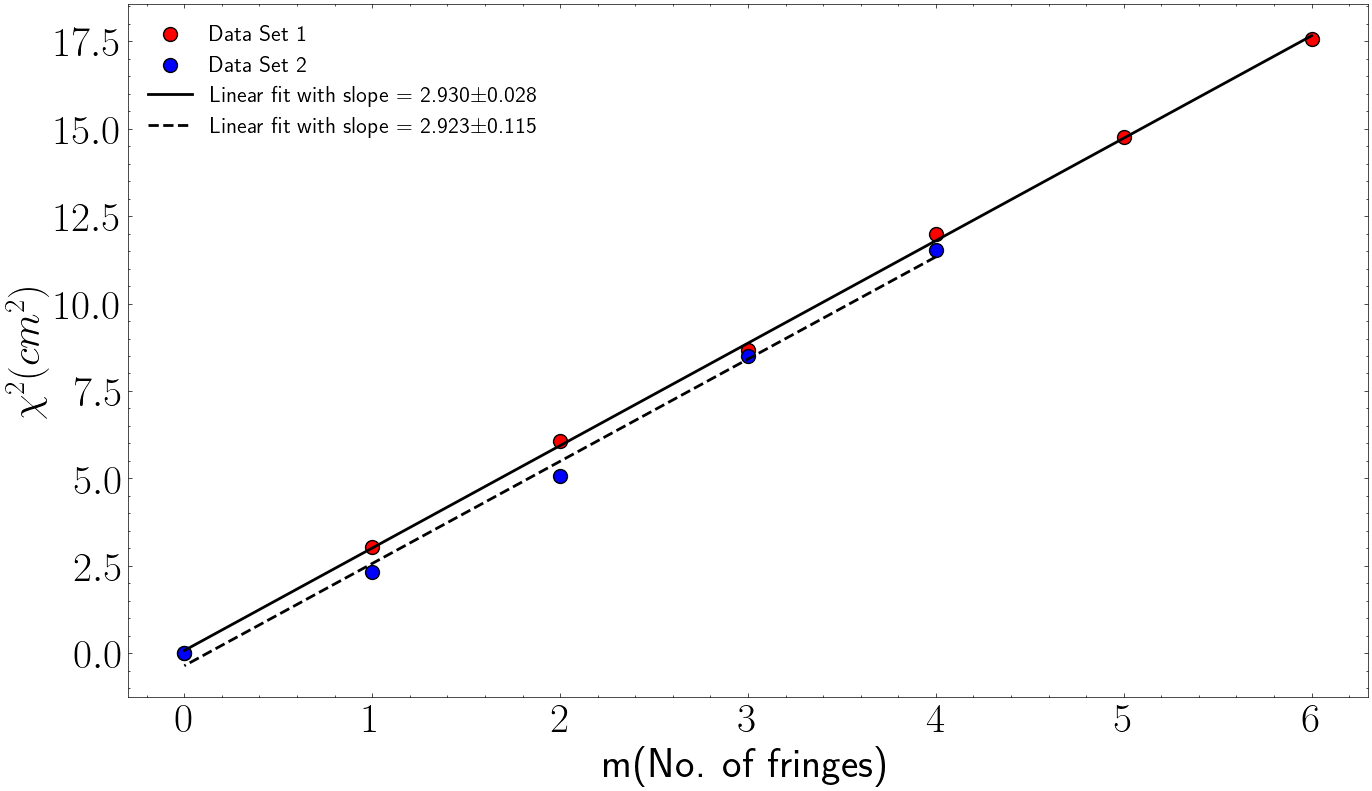

In [12]:
plt.figure(figsize=(16,9))
plt.scatter(mred, chired, s=100,color='r',edgecolor='black', label='Data Set 1')
plt.scatter(mred1, chired1, s=100,color='b',edgecolor='black', label='Data Set 2')
plt.plot(mred, linfit(mred, *redfit[0]),lw=2, color='k', label='Linear fit with slope = {:.3f}'.format(redfit[0][0])+r"$\pm$"+'{:.3f}'.format(rferr[0]))
plt.plot(mred1, linfit(mred1, *red1fit[0]),lw=2, color='k', ls='--', label='Linear fit with slope = {:.3f}'.format(red1fit[0][0])+r"$\pm$"+'{:.3f}'.format(rf1err[0]))
plt.legend()
plt.xlabel('m(No. of fringes)')
plt.ylabel(r'$\chi^2 (cm^2)$')

plt.savefig('redfit.png', dpi=300)

In [17]:
D = 83.9
L = 655 * 10**(-7)
slope = redfit[0][0]
sloperr = rferr[0]
d = (L*D**2)/(slope)
derr = d * np.sqrt((sloperr/slope)**2)
d,derr

(np.float64(0.15736966724497267), np.float64(0.0015099870965883796))

In [18]:
D1 = 82.6 

slope1 = red1fit[0][0]
slope1err = rf1err[0]
d1 = (L*D1**2)/(slope1)
d1err = d1 * np.sqrt((slope1err/slope1)**2)
d1,d1err

(np.float64(0.15288771125555936), np.float64(0.0060065661074989425))

In [22]:
avgd = (d/derr**2 + d1/d1err**2)/(1/derr**2 + 1/d1err**2)
avger = np.sqrt((derr**2 + d1err**2)/2)
avgd, avger

(np.float64(0.1571032588265571), np.float64(0.0043794347486643985))

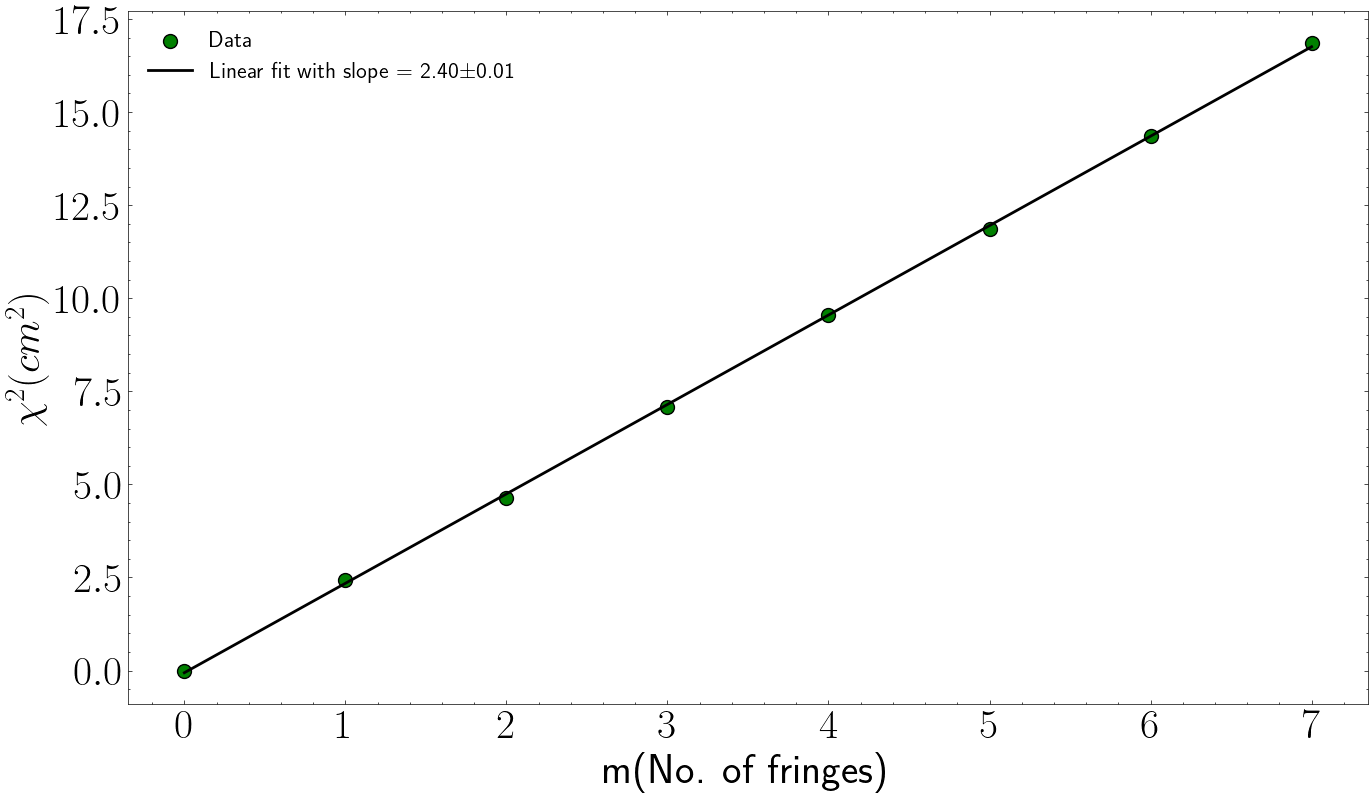

In [13]:
plt.figure(figsize=(16,9))
plt.scatter(mgreen, chigreen, s=100,color='g',edgecolor='black', label='Data')
plt.plot(mgreen, linfit(mgreen, *greenfit[0]),lw=2, color='k', label='Linear fit with slope = {:.2f}'.format(greenfit[0][0])+r"$\pm$"+'{:.2f}'.format(gferr[0]))
plt.legend()
plt.xlabel('m(No. of fringes)')
plt.ylabel(r'$\chi^2 (cm^2)$')

plt.savefig('greenfit.png', dpi=300)

In [24]:
lam = d*greenfit[0][0]/(D**2)
lam*10**(7)

np.float64(536.9614330937114)

In [25]:
lamerr = lam * np.sqrt((derr/d)**2 + (gferr[0]/greenfit[0][0])**2)
lamerr*10**(7)

np.float64(6.001443843154455)